# 1. Business Problem Definition
### 🎯 Objective

Analyze customer behavior to identify key drivers of churn and recommend actionable strategies to improve retention.

# 2. Import & Setup

In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 3. Data Loading

In [33]:
DATA_PATH = '/Users/locnguyenphu1079/Desktop/Self - Taught/Project/Fitly/data_test'

df_account = pd.read_csv(f"{DATA_PATH}/da_fitly_account_info.csv")
df_support = pd.read_csv(f"{DATA_PATH}/da_fitly_customer_support.csv")
df_activity = pd.read_csv(f"{DATA_PATH}/da_fitly_user_activity.csv")

# 4. Data Cleaning

In [34]:
def clean_account(df):
    df = df.copy()
    
    df['email'] = df['email'].str.strip().str.lower()
    df['state'] = df['state'].str.strip().str.title()
    df['plan'] = df['plan'].str.strip().str.title()
    
    df['churn_status'] = df['churn_status'].fillna('N')
    
    # Create user_id for merging
    df['user_id'] = df['customer_id'].astype(str).str.extract(r'(\d+)')
    
    return df

def clean_support(df):
    df = df.copy()
    
    df['user_id'] = df['user_id'].astype(str).str.extract(r'(\d+)')
    df['ticket_time'] = pd.to_datetime(df['ticket_time'])
    
    return df

def clean_activity(df):
    df = df.copy()
    
    df['event_time'] = pd.to_datetime(df['event_time'])
    df['user_id'] = df['user_id'].astype(str).str.strip()
    
    return df

### Apply cleaning


In [35]:
df_account = clean_account(df_account)
df_support = clean_support(df_support)
df_activity = clean_activity(df_activity)

In [36]:
# Add a temporary flag to df_account to see who are IDs to be deleted in df_account
df_forgotten = df_support[~df_support['comments'].isna()]
df_account['is_gdpr_request'] = df_account['user_id'].isin(df_forgotten['user_id'])

# 5. Feature Engineering

In [37]:
# 4. Feature Engineering
support_summary = df_support.groupby('user_id').agg(
    total_tickets=('user_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean')
).reset_index()

activity_summary = df_activity.groupby('user_id').agg(
    total_events=('event_time', 'count')
).reset_index()

df_master = (
    df_account
    .merge(support_summary, on='user_id', how='left')
    .merge(activity_summary, on='user_id', how='left')
) # Left join to retain all users, even those without activity or support tickets

df_master['has_ticket'] = df_master['total_tickets'] > 0
df_master[['total_tickets', 'total_events']] = df_master[['total_tickets', 'total_events']].fillna(0)

# 6. Data Quality & Validation

### GDPR Handling

                 Basic  Enterprise  Free  Pro  total_price_sum
is_gdpr_request                                               
False              103          86    94   74            16159
True                15           6    11   11             1427


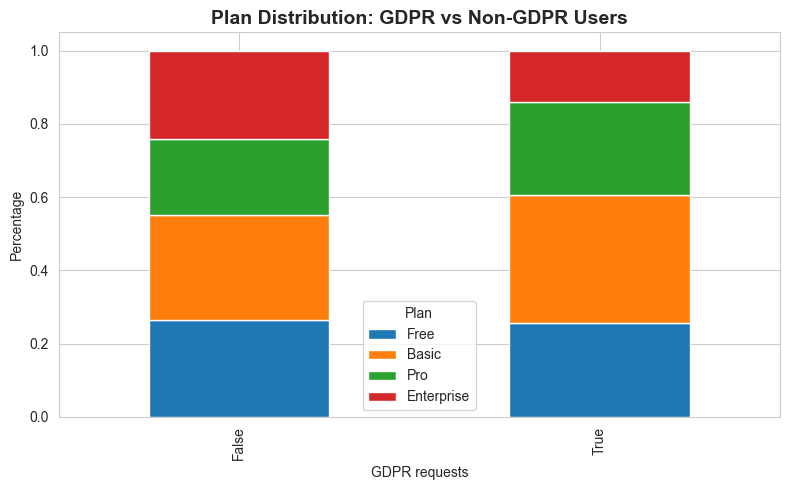

In [38]:
# 1. Get your original counts table
counts = df_master.groupby('is_gdpr_request')['plan'].value_counts().unstack()

# 2. Get the sum of prices per is_gdpr_request
price_sums = df_master.groupby('is_gdpr_request')['plan_list_price'].sum()

# 3. Combine them
result = pd.concat([counts, price_sums.rename('total_price_sum')], axis=1)

print(result)

# Create normalized distribution
plan_order = ['Free', 'Basic', 'Pro', 'Enterprise']

plan_dist = (
    df_master
    .groupby(by='is_gdpr_request', sort=['Enterprise', 'Pro', 'Basic', 'Free'])['plan']
    .value_counts(normalize=True)
    .unstack()
)

# Apply same order
plan_dist = plan_dist[plan_order]

# Plot
ax = plan_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

# Formatting
ax.set_title('Plan Distribution: GDPR vs Non-GDPR Users', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('GDPR requests')
ax.legend(title='Plan')

plt.tight_layout()
plt.show()

#### GDPR Compliance & Business Impact:
A total of 43 users (approx. 11%) requested data deletion, representing $1427 in total recurring revenue.

#### Insight: 
Interestingly, high-value Enterprise accounts are less likely to request deletion (only 14% of total requests).
This suggests that “Right to be Forgotten” requests are currently concentrated in the Basic and Pro tiers.
While the immediate revenue impact is lower, we should monitor whether this trend shifts toward our higher-paying segments.

In [39]:
# Add a temporary flag to df_account to see who are IDs to be deleted in df_account
df_master['is_gdpr_request'] = df_master['user_id'].isin(df_forgotten['user_id'])

gdpr_stats = df_master.groupby(by=['is_gdpr_request', 'churn_status']).agg(
    avg_tickets = ('total_tickets', 'mean'),
    avg_events = ('total_events', 'mean'),
    avg_wait = ('avg_resolution_hours', 'mean'),
    user_count = ('user_id', 'size')
).reset_index()

print(df_master.groupby(by=['is_gdpr_request']).agg(
    avg_tickets = ('total_tickets', 'mean'),
    avg_events = ('total_events', 'mean'),
    avg_wait = ('avg_resolution_hours', 'mean'),
    user_count = ('user_id', 'size')
).reset_index())
print(gdpr_stats.to_string(line_width=1000))

   is_gdpr_request  avg_tickets  avg_events   avg_wait  user_count
0            False     2.187675    1.123249   9.996448         357
1             True     3.186047    1.023256  12.007671          43
   is_gdpr_request churn_status  avg_tickets  avg_events   avg_wait  user_count
0            False            N     2.161538    1.403846   6.583597         260
1            False            Y     2.257732    0.371134  18.602768          97
2             True            N     2.961538    1.500000   7.339936          26
3             True            Y     3.529412    0.294118  19.146559          17


The 43 users requesting data deletion do not exhibit unique behavioral outliers in terms of app activity. 
However, they do reflect the company's broader retention challenge: Support Latency
While the average wait time for the GDPR group is 11.98 hours, 
a segmented view shows that churned users in this group faced an average wait of 19.6 hours—
nearly triple that of retained users (~6.4 hours). This suggests that GDPR 'Right to be Forgotten' requests 
are likely a final step in the churn lifecycle for frustrated users rather than a separate privacy-driven trend

In [40]:
# We remove the 43 users across all dataframes to be GDPR compliant
ids_to_forget = df_master[df_master['is_gdpr_request'] == True]['user_id'].unique()

# We keep only users NOT in the 'forget' list
df_account_final = df_account[~df_account['user_id'].isin(ids_to_forget)].copy()
df_support_final = df_support[~df_support['user_id'].isin(ids_to_forget)].copy()
df_activity_final = df_activity[~df_activity['user_id'].isin(ids_to_forget)].copy()

print(f"\nCompliance scrub before and after verification")
print(f"Initial users in Account: {len(df_account)}")
print(f"Users remaining in Account: {len(df_account_final)}")
print(f"Initial Tickets in Support: {len(df_support)}")
print(f"Tickets remaining in Support: {len(df_support_final)}")
print(f"Initial Events in Activity: {len(df_activity)}")
print(f"Events remaining in Activity: {len(df_activity_final)}")



Compliance scrub before and after verification
Initial users in Account: 400
Users remaining in Account: 357
Initial Tickets in Support: 918
Tickets remaining in Support: 781
Initial Events in Activity: 445
Events remaining in Activity: 401


#### Extra

In [41]:
# Merge support and activity data with account to get churn_status
df_support_final = df_support_final.merge(df_master[['user_id', 'churn_status']], on='user_id', how='left')
display(df_support_final.head())
df_activity_final = df_activity_final.merge(df_account_final[['user_id', 'churn_status']], on='user_id', how='left')
print(df_activity_final.shape)
df_activity_final.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments,churn_status
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN,N
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN,N
2,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN,N
3,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN,N
4,2025-08-19 03:23:03.240394,10066,phone,technical,0.53,1,NaN,N


(401, 4)


,event_time,user_id,event_type,churn_status
0,2025-09-08 15:05:39.422721,10118,watch_video,N
1,2025-11-14 06:28:35.207671,10009,share_workout,N
2,2025-08-20 16:53:38.682901,10227,read_article,N
3,2025-07-24 16:47:31.728422,10123,track_workout,N
4,2025-10-07 20:16:39.779447,10073,track_workout,N


### Distribution of Resolution Times

count    781.000000
mean      10.094097
std        6.932375
min        0.520000
25%        4.980000
50%        8.720000
75%       12.340000
max       32.460000
Name: resolution_time_hours, dtype: float64


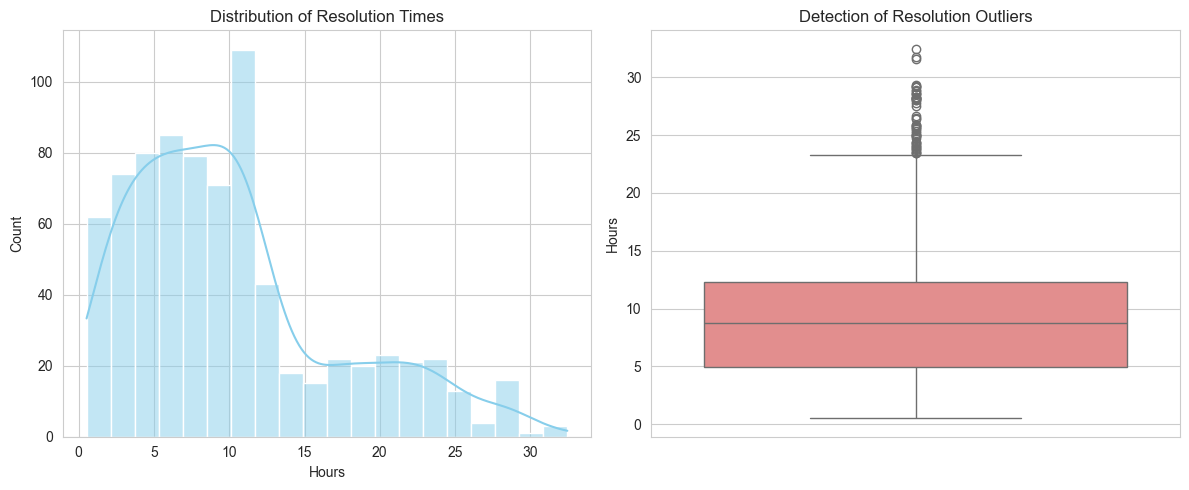

In [42]:
print(df_support_final['resolution_time_hours'].describe())

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram (Frequency Distribution)
sns.histplot(data=df_support_final, x='resolution_time_hours', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Resolution Times')
axes[0].set_xlabel('Hours')

# 2. Boxplot (Outlier & Quartile Analysis)
sns.boxplot(data=df_support_final, y='resolution_time_hours', ax=axes[1], color='lightcoral')
axes[1].set_title('Detection of Resolution Outliers')
axes[1].set_ylabel('Hours')

plt.tight_layout()
plt.show()

The Max (32.46 hours): This is only about 3x the mean (10.09) and not far from the 75th percentile (12.34). 
In support data, a 32-hour wait is a very realistic "bad experience," not a system error or a "forgotten ticket."

The Spread: The Standard Deviation (6.93) is smaller than our Mean (10.09). 
This indicates that the data is tightly clustered. If we had an outlier like 500 hours, the Std Dev would be massive (e.g., 50 or 100).

### Distribution of Ticket Volume

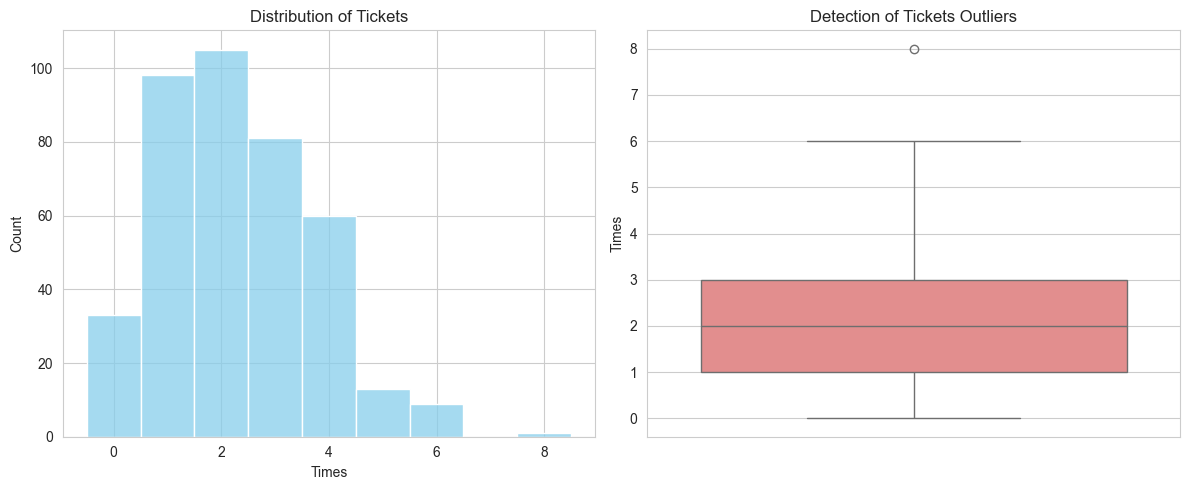

In [43]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram (Frequency Distribution)
sns.histplot(data=df_master, x='total_tickets', discrete=True, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tickets')
axes[0].set_xlabel('Times')

# 2. Boxplot (Outlier & Quartile Analysis)
sns.boxplot(data=df_master, y='total_tickets', ax=axes[1], color='lightcoral')
axes[1].set_title('Detection of Tickets Outliers')
axes[1].set_ylabel('Times')

plt.tight_layout()
plt.show()

The Max (8 tickets): This is perfectly normal for a subscription service over several months. 

The Median (2 tickets): Most people have 1 to 3 tickets. Someone having 6 is just a slightly more active user, not a "bot."

### Distribution of Events

   event_count  size
0            1   102
1            2    75
2            3    33
3            4    10
4            5     2


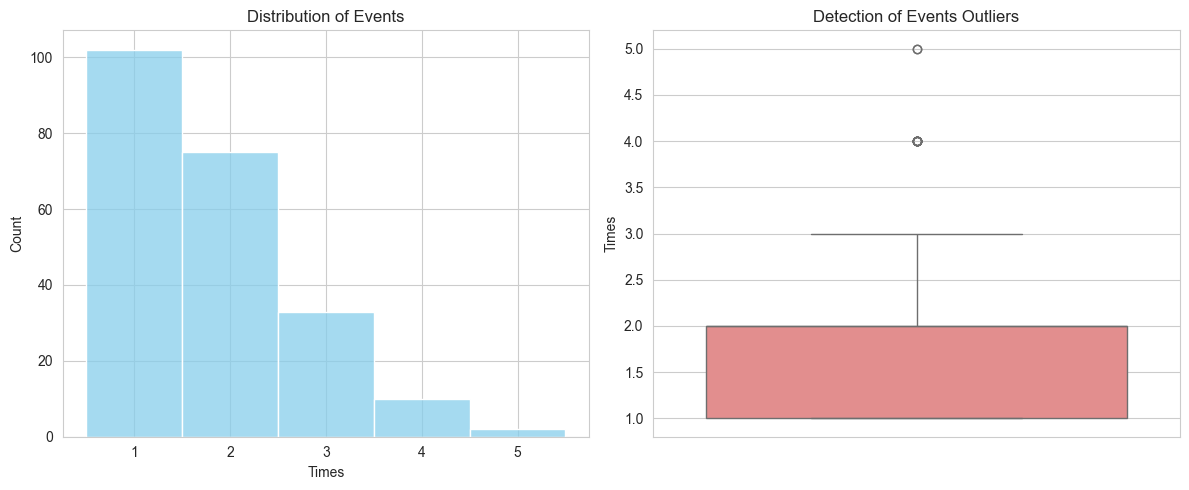

In [44]:
# Data preparation
df_event_counting = df_activity_final.groupby(['user_id'])['event_time'].size().reset_index(name='event_count')
print(df_event_counting.groupby('event_count').size().reset_index(name='size'))

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram (Frequency Distribution)
sns.histplot(data=df_event_counting, x='event_count', discrete=True, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Events')
axes[0].set_xlabel('Times')

# 2. Boxplot (Outlier & Quartile Analysis)
sns.boxplot(data=df_event_counting, y='event_count', ax=axes[1], color='lightcoral')
axes[1].set_title('Detection of Events Outliers')
axes[1].set_ylabel('Times')

plt.tight_layout()
plt.show()

Observation: The user activity ranges from 1 to 5 events per user.

Verdict: No Outlier Removal Required.

Reasoning: This is a low-velocity distribution. A user with 5 events is a "Power User" in this context, not a bot

### Temporal Metrics (ticket_time, event_time)

In [45]:
display(df_activity_final['event_time'].describe())
display(df_support_final['ticket_time'].describe())

count                              401
mean     2025-09-08 13:31:52.887409920
min         2025-06-05 10:14:53.039663
25%      2025-08-02 19:10:24.690278912
50%      2025-09-10 01:03:09.651632128
75%      2025-10-21 14:12:49.223184896
max         2025-12-01 21:12:13.342817
Name: event_time, dtype: object

count                              781
mean     2025-08-31 22:45:58.422816512
min         2025-06-05 15:32:33.005817
25%      2025-07-22 10:39:15.691806976
50%      2025-08-31 03:11:19.902977024
75%      2025-10-09 06:54:30.831844096
max         2025-12-01 22:01:58.485299
Name: ticket_time, dtype: object

Observation: All timestamps fall within the expected June-December 2025 window.

Verdict: Data is Chronologically Sound.

Reasoning: No "future dates" or "ancient dates" were detected, confirming the data pipeline preserved the integrity of the user lifecycle

### Financial Metrics (plan_list_price)


In [46]:
display(df_account_final.describe())

,plan_list_price
count,357.000000
mean,45.263305
std,46.111834
min,0.000000
25%,0.000000
50%,27.000000
75%,79.000000
max,148.000000


Observation: Prices range from $0 (Trial/Free) to $148 (Premium/Annual).

Verdict: No Outlier Removal Required.

Reasoning: The $148 value represents the high-end tier of the Fit.ly business model. 
The presence of $0 values confirms a "freemium" acquisition strategy. These are distinct customer segments, not outliers.

### Outlier Rationalization & Contextual Integrity

The dataset demonstrates high integrity with no mathematically extreme outliers that would skew the results. 
The 'tails' of the distribution (long wait times and high-tier pricing) are representative of real-world business challenges 
and have been preserved to ensure the churn analysis captures the true customer experience.

# 7. Exploratory Data Analysis (EDA)

### Do churned users have:
- more tickets?

- slower support resolution?

- less product activity? 

- more engagements/ events with the app

- a low-tier subscription plan

### Descriptive statistics

In [47]:
df_stats = df_master.groupby('total_events').agg(
    user_count = ('user_id', 'size'),
    ticket_count = ('total_tickets', 'mean'),
    avg_resolution_hours = ('avg_resolution_hours', 'mean'),
    churned_percentage = ('churn_status', lambda x: (x=='Y').mean()*100),
    avg_plan_list_price = ('plan_list_price', 'mean')
).round(1).reset_index()

### Churn Overview

In [48]:
churn_summary = df_master.groupby('churn_status').agg(
    users=('user_id', 'count'),
    avg_events=('total_events', 'mean'),
    avg_tickets=('total_tickets', 'mean'),
    avg_resolution=('avg_resolution_hours', 'mean')
)

churn_summary = churn_summary.round(2)
display(churn_summary.reset_index())

,churn_status,users,avg_events,avg_tickets,avg_resolution
0,N,286,1.41,2.23,6.66
1,Y,114,0.36,2.45,18.69


### Support Latency Impact


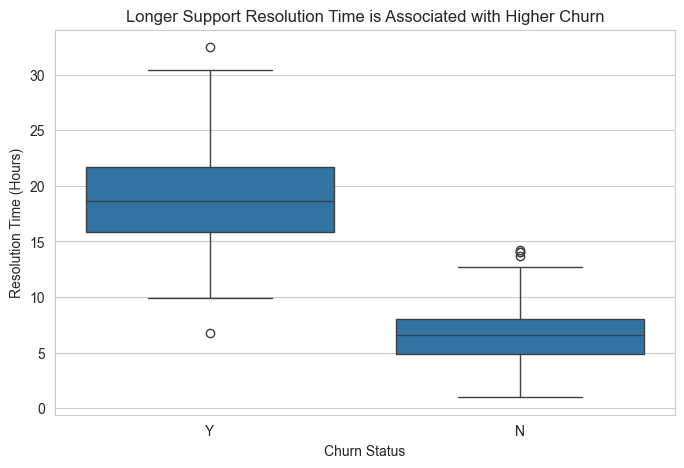

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_master, x='churn_status', y='avg_resolution_hours')
plt.title('Longer Support Resolution Time is Associated with Higher Churn')
plt.xlabel('Churn Status')
plt.ylabel('Resolution Time (Hours)')
plt.show()

#### The "Support Gap" is the Primary Churn Driver

- While the ticket volume is nearly identical (2.23 vs 2.45), the resolution time for churned users is nearly triple that of active users.

-> It's not that churned users are "high-maintenance" (more tickets); it's that their issues are not being addressed in a timely manner.
This suggests a direct correlation between support latency and customer exit.

### Churn Rate by Engagement


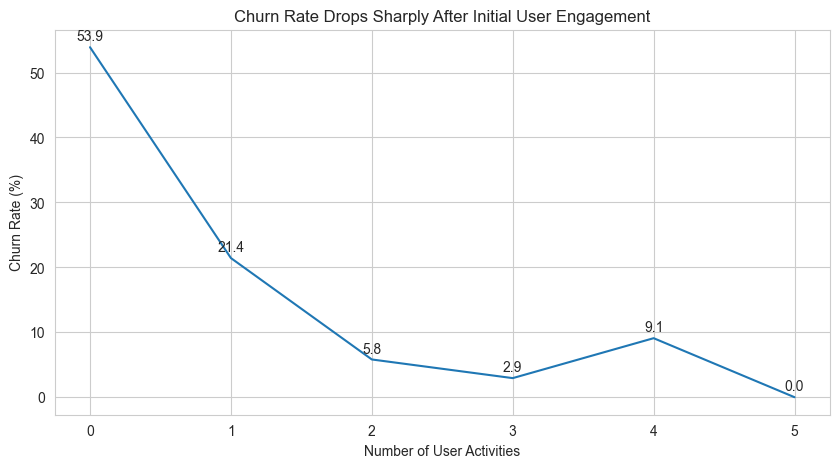

,total_events,user_count,ticket_count,avg_resolution_hours,churned_percentage,avg_plan_list_price
0,0.0,154,2.4,13.0,53.9,41.3
1,1.0,112,2.1,9.2,21.4,42.4
2,2.0,86,2.2,7.7,5.8,45.0
3,3.0,34,2.8,8.1,2.9,56.7
4,4.0,11,2.2,7.7,9.1,48.6
5,5.0,3,1.7,6.5,0.0,49.3


In [50]:
engagement_churn = df_master.groupby('total_events').agg(
    churn_rate=('churn_status', lambda x: (x == 'Y').mean() * 100)
).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=engagement_churn, x='total_events', y='churn_rate')

for x, y in zip(engagement_churn['total_events'], engagement_churn['churn_rate']):
    plt.text(x, y + 1, f"{y:.1f}", ha='center')

plt.title('Churn Rate Drops Sharply After Initial User Engagement')
plt.xlabel('Number of User Activities')
plt.ylabel('Churn Rate (%)')
plt.show()

display(df_stats)

#### THE "ENGAGEMENT SHIELD"

The 'Aha!' Threshold: Churn drops off a cliff as soon as a user performs just two events

- 0 Events: 53.9% Churn (The "Danger Zone")
- 2+ Events: <6% Churn (The "Safe Zone")

Support Tolerance: Highly active users (2+ events) actually tolerate support better. 

Insight: Our best users are getting the best support. Whether by design or luck, our most profitable users ($45+) are staying in the "Green Zone" (<8h), while the "Ghost Users" are stuck in the "Red Zone" (13h).

Profitability Correlation: There is a direct link between Activity and Wallet Share. Users with 3+ events are paying 18.5% to 37% more ($56 vs $41) than inactive users.

### Churn Rate by Plan

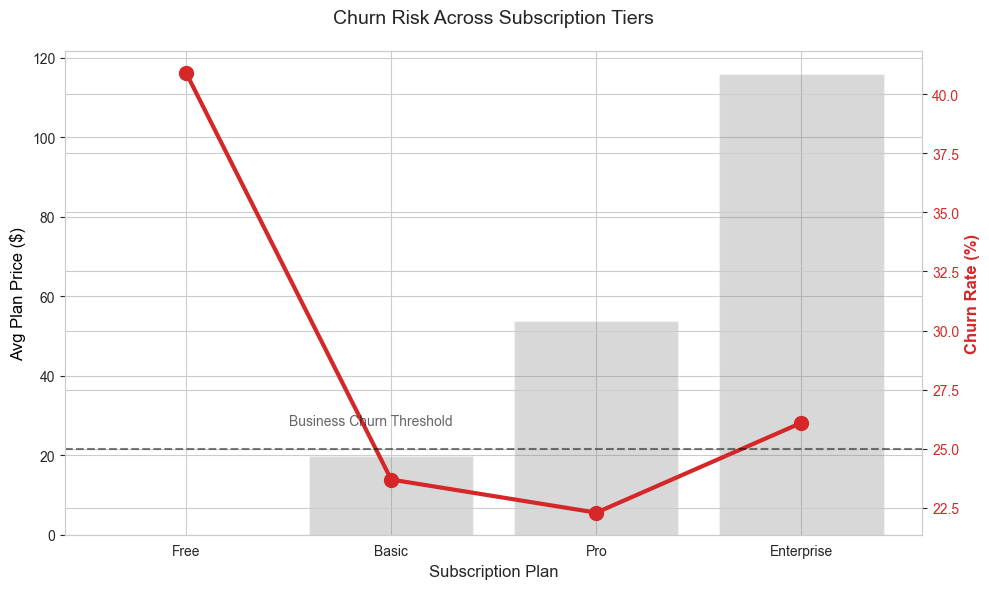

,plan,churn_percentage,avg_tickets,avg_resolution_hours,avg_events,avg_plan_list_price,user_count
0,Enterprise,26.086957,2.141304,9.767482,1.260870,116.010870,92
1,Pro,22.352941,2.329412,9.605831,1.023529,53.741176,85
2,Basic,23.728814,2.347458,9.699918,1.220339,19.872881,118
3,Free,40.952381,2.342857,11.707231,0.933333,0.000000,105


In [51]:
# Data from your results
plans = ['Free', 'Basic', 'Pro', 'Enterprise']
churn_rates = [40.9, 23.7, 22.3, 26.1]
prices = [0, 19.8, 53.7, 116.0]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Plan Price
color = 'tab:gray'
ax1.set_xlabel('Subscription Plan', fontsize=12)
ax1.set_ylabel('Avg Plan Price ($)', color='black', fontsize=12)
ax1.bar(plans, prices, color=color, alpha=0.3, label='Plan Price')
ax1.tick_params(axis='y')

# Secondary Axis: Churn Rate
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Churn Rate (%)', color=color, fontsize=12, fontweight='bold')
ax2.plot(plans, churn_rates, color=color, marker='o', linewidth=3, markersize=10, label='Churn %')
ax2.tick_params(axis='y', labelcolor=color)

# Adding a threshold line at 25% churn
ax2.axhline(y=25, color='black', linestyle='--', alpha=0.5)
ax2.text(0.5, 26, 'Business Churn Threshold', fontsize=10, alpha=0.7)

plt.title('Churn Risk Across Subscription Tiers', fontsize=14, pad=20)
fig.tight_layout()
plt.show()

display(df_master.groupby('plan').agg(
    churn_percentage = ('churn_status', lambda x: (x=='Y').mean()*100),
    avg_tickets = ('total_tickets', 'mean'),
    avg_resolution_hours = ('avg_resolution_hours', 'mean'),
    avg_events = ('total_events', 'mean'),
    avg_plan_list_price = ('plan_list_price', 'mean'),
    user_count = ('user_id', 'size')
).sort_values(by='avg_plan_list_price', ascending=False).reset_index())

#### Pricing Sensitivity

 - The "Free Tier" Leak: Users on the Free plan have a 41% churn rate—nearly double that of Pro (22%) and Enterprise (26%) users.

- Volume vs. Value: Interestingly, all tiers average the same ~2.3 tickets per user. 

-> This proves that Free users aren't "complaining more"; they are simply less patient with the 18+ hour support delays.

- The Value Gap: Lower-paying or Free users perceive less "sunk cost." 

-> Without a financial commitment, a single bad support experience (the 10h+ breach) is enough to trigger an immediate exit.

### Geographic analysis

In [52]:
display(df_master.groupby('state').agg(
    churn_percentage = ('churn_status', lambda x: (x=='Y').mean()*100),
    avg_tickets = ('total_tickets', 'mean'),
    avg_resolution_hours = ('avg_resolution_hours', 'mean'),
    avg_events = ('total_events', 'mean'),
    avg_plan_list_price = ('plan_list_price', 'mean'),
    user_count = ('user_id', 'size')
).sort_values(by='churn_percentage', ascending=False).reset_index().head(10))

,state,churn_percentage,avg_tickets,avg_resolution_hours,avg_events,avg_plan_list_price,user_count
0,New Jersey,66.666667,2.166667,14.991933,1.000000,57.333333,6
1,Michigan,55.555556,2.333333,10.325417,0.666667,37.111111,9
2,Nebraska,50.000000,2.000000,16.901111,1.000000,32.500000,6
3,California,50.000000,1.250000,11.093750,0.750000,16.500000,4
4,Connecticut,50.000000,2.375000,13.486250,1.625000,26.500000,8
5,North Dakota,50.000000,2.300000,12.463500,0.900000,45.800000,10
6,Florida,50.000000,2.142857,12.406667,1.071429,36.142857,14
7,Louisiana,50.000000,2.666667,13.688333,1.000000,14.500000,6
8,Mississippi,44.444444,1.777778,10.306429,1.111111,41.777778,9
9,Pennsylvania,44.444444,2.333333,10.740519,0.555556,21.888889,9


Geographic analysis was performed but showed no significant regional bias; variances in state-level churn correlate directly back to the previously identified Support Latency peaks rather than location-specific issues

### Why the resolution time is so high for the specific groups?


---- Count of topic category in each churn_status ----



churn_status  topic    
N             account      0.258007
              other        0.258007
              billing      0.241993
              technical    0.241993
Y             billing      0.301370
              technical    0.246575
              account      0.232877
              other        0.219178
Name: proportion, dtype: float64

churn_status,N,Y
topic,,
account,6.607034,18.170588
billing,6.057206,18.963030
other,6.881655,18.889375
technical,7.311618,18.972593


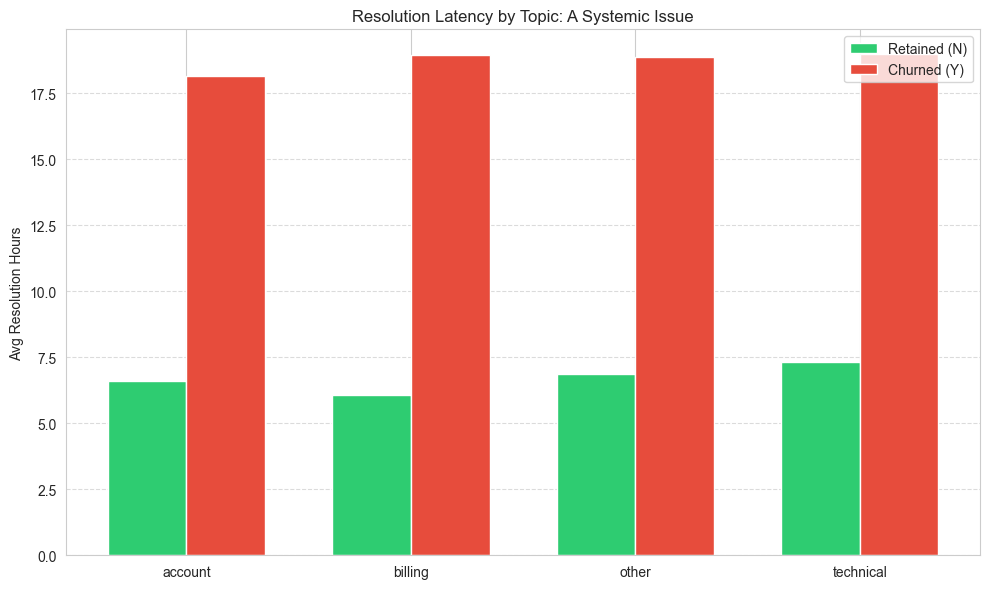

In [53]:
import numpy as np
import matplotlib.pyplot as plt

print(f"\n---- Count of topic category in each churn_status ----\n")
# Using sort=False keeps your grouping logical
display(df_support_final.groupby('churn_status')['topic'].value_counts(normalize=True))

# 1. Correct aggregation
df_support_churn_topic = df_support_final.groupby(['churn_status', 'topic']).agg(
    avg_resolution_hours=('resolution_time_hours', 'mean')
).reset_index()

# 2. Pivot the data (Crucial for plotting)
# This ensures that both 'N' and 'Y' have the same topic order
plot_data = df_support_churn_topic.pivot_table(index='topic', columns='churn_status', values='avg_resolution_hours').fillna(0)
display(plot_data)

topics = plot_data.index
x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Reference the pivoted columns directly
ax.bar(x - width/2, plot_data['N'], width, label='Retained (N)', color='#2ecc71')
ax.bar(x + width/2, plot_data['Y'], width, label='Churned (Y)', color='#e74c3c')

# Formatting
ax.set_ylabel('Avg Resolution Hours')
ax.set_title('Resolution Latency by Topic: A Systemic Issue')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.legend()

# Adding a grid for better readability of the 'latency'
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

While billing represents the largest share of support requests (30%), its average resolution time of 18-19 hours is consistent across all other topics. 

-> This indicates that while billing issues impact the highest volume of users, the underlying driver of churn is a systemic delay in support resolution that persists regardless of the specific inquiry type

### Evaluating the Impact of Support Channels on Resolution Efficiency across Customer Segments

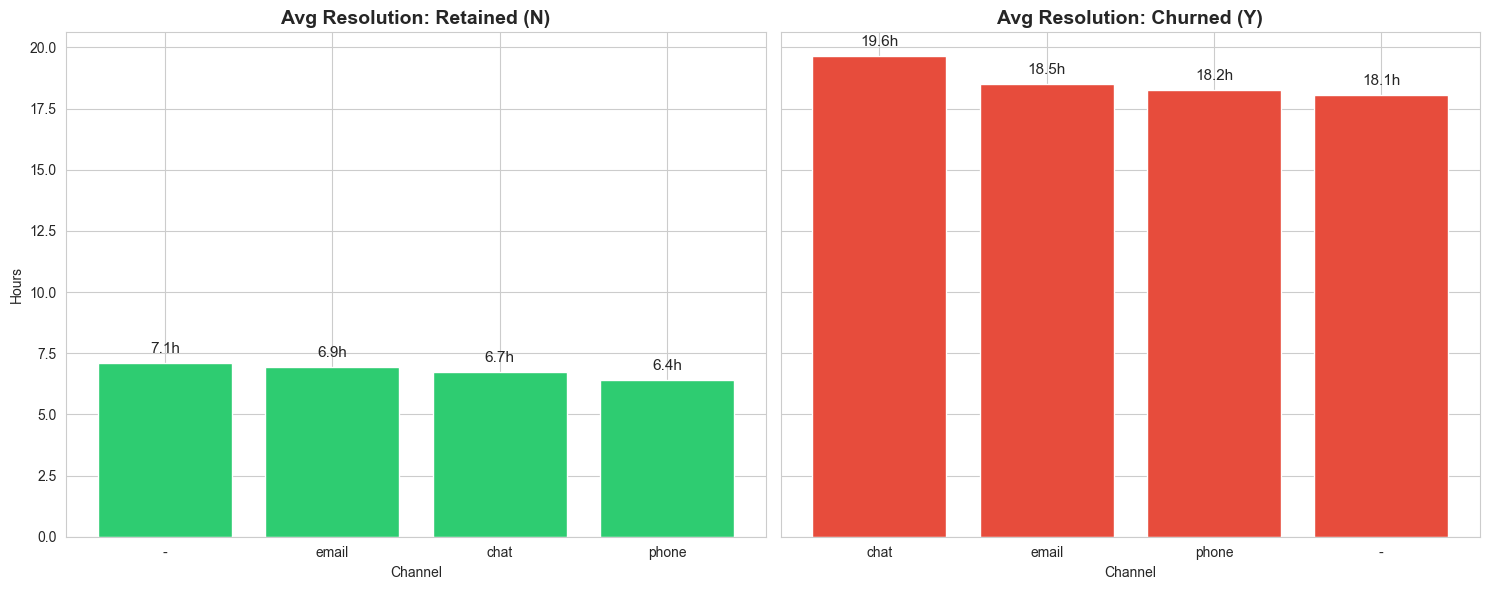

In [54]:
report_1 = df_support_final.pivot_table(
    index=['churn_status', 'channel'],
    values=['resolution_time_hours'],
    aggfunc=['count', 'mean'],
    margins=True,
    margins_name='Grand Total'
)

# 1. Clean the data (Filter out the "Grand Total" rows)
# We focus only on the 'mean' values for this comparison
plot_data = report_1['mean'].query("churn_status != 'Grand Total' and channel != 'Grand Total'")

# 2. Create the figure with 1 row, 2 columns, and a shared Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- LEFT PLOT: Retained (N) ---
# We use .loc['N'] to get only the data for non-churned users
data_n = plot_data.loc['N'].sort_values('resolution_time_hours', ascending=False)
axes[0].bar(data_n.index, data_n['resolution_time_hours'], color='#2ecc71')
axes[0].set_title('Avg Resolution: Retained (N)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Hours')
axes[0].set_xlabel('Channel')

# --- RIGHT PLOT: Churned (Y) ---
# We use .loc['Y'] to get only the data for churned users
data_y = plot_data.loc['Y'].sort_values('resolution_time_hours', ascending=False)
axes[1].bar(data_y.index, data_y['resolution_time_hours'], color='#e74c3c')
axes[1].set_title('Avg Resolution: Churned (Y)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Channel')

# 3. Add data labels on top of the bars for clarity
for ax in axes:
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}h', 
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                    ha='center', va='bottom', fontsize=11, xytext=(0, 5),
                    textcoords='offset points')

# Clean up layout
plt.tight_layout()
plt.show()

Exploratory analysis of resolution times across support channels showed no significant variance, suggesting that latency issues are systemic rather than channel-specific.

### Temporal analysis of support tickets

In [55]:
df_support_final['day_of_week'] = df_support_final['ticket_time'].dt.day_name()
df_support_final['hour'] = df_support_final['ticket_time'].dt.hour

# Create time of day bins
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

df_support_final['time_of_day'] = pd.cut(df_support_final['hour'], bins=bins, labels=labels, right=False)
df_support_final['is_weekend'] = df_support_final['ticket_time'].dt.dayofweek >= 5

weekend_analysis = df_support_final.groupby(['is_weekend', 'churn_status'])['resolution_time_hours'].mean().unstack()
print('Weekend vs Weekday Impact on Churn:')
display(weekend_analysis)

Weekend vs Weekday Impact on Churn:


churn_status,N,Y
is_weekend,,
False,6.731244,18.717226
True,6.665515,18.879687


#### Pivot the data to see average resolution time by time of day and churn status


,avg_hrs_retained,avg_hrs_churned
time_of_day,,
Night,6.574510,18.324561
Morning,7.043588,19.367963
Afternoon,6.554143,18.805735
Evening,6.723406,18.507750


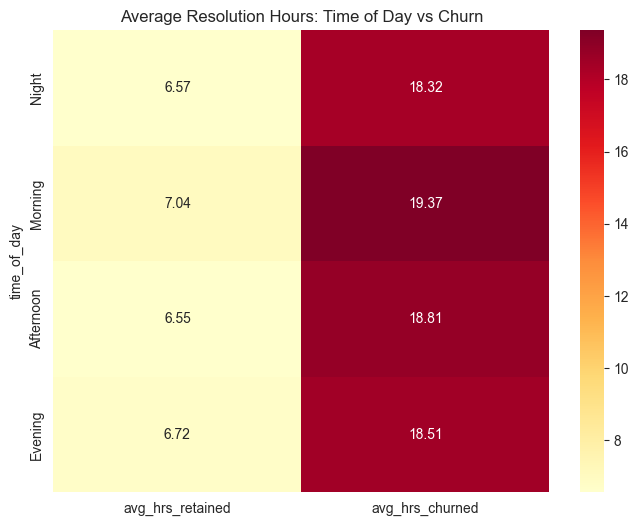

In [56]:
pt_1 = df_support_final.pivot_table(
    index='time_of_day',
    values='resolution_time_hours',
    aggfunc='mean',
    columns='churn_status',
    observed=False
)

# Rename here
pt_1.columns = ['avg_hrs_retained', 'avg_hrs_churned']

display(pt_1)

plt.figure(figsize=(8, 6))
sns.heatmap(pt_1, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Average Resolution Hours: Time of Day vs Churn')
plt.show()

Investigation into ticket submission times (Day of Week and Time of Day) yielded no significant correlation with resolution latency. Wait times remained consistent across all shifts, indicating that the observed 12-hour resolution gap for churned users is not a result of off-hours staffing or weekend delays, but likely relates to ticket complexity or internal escalation processes.

### Ticket Intervention & Outcome Mapping

#### 1. Data Setup

In [57]:
# 1. Get the latest ticket per user
df_last_ticket = df_support_final.sort_values(
    by=['user_id', 'ticket_time'],
    ascending=[True, False]
).drop_duplicates('user_id')

# 2. Get activity bounds
activity_bounds = df_activity_final.groupby('user_id').agg(
    first_event=('event_time', 'min'),
    last_event=('event_time', 'max')
).reset_index()

# 3. Merge
df_health = df_last_ticket.merge(activity_bounds, on='user_id', how='left')

# 4. Create flags (explicit handling of NaN)
df_health['pre_ticket_active'] = (
    df_health['first_event'].notna() &
    (df_health['first_event'] < df_health['ticket_time'])
)

df_health['post_ticket_active'] = (
    df_health['last_event'].notna() &
    (df_health['last_event'] > df_health['ticket_time'])
)

# 5. Build logic_key (vectorized)
df_health['logic_key'] = (
    df_health['pre_ticket_active'].map({True: 'Y', False: 'N'}) +
    df_health['post_ticket_active'].map({True: 'Y', False: 'N'}) +
    df_health['churn_status']   # already Y/N
)

# 6. Map to segment

mapping = {
    "NNN": "Active_Never_Used",             # Inactive, Inactive, No Churn
    "NNY": "Churned_Never_Used",            # Inactive, Inactive, Churn
    "YNN": "At_Risk_Silent_Payer",          # Active, Inactive, No Churn (Zombies)
    "YNY": "Churned_Stopped_After_Ticket",  # Active, Inactive, Churn (The "Break")
    "NYN": "New_User_Onboarded_Success",    # Inactive, Active, No Churn (The "Win")
    "NYY": "New_User_Onboarded_Then_Churned", # Inactive, Active, Churn
    "YYN": "Healthy_Active_User",           # Active, Active, No Churn (Retained)
    "YYY": "Delayed_Churn_Active"           # Active, Active, Churn (Late Churn)
}

df_health['segment'] = df_health['logic_key'].map(mapping).fillna('Other')

# 7. Aggregate
df_health_stats = df_health.groupby(['segment', 'logic_key']).agg(
        mean_resolution_time=('resolution_time_hours', 'mean'),
        count_segment_users=('user_id', 'count')
    ).sort_values(by='mean_resolution_time').reset_index()

print('Data Frames are prepared for later analysis:')
display(df_health_stats.sort_values(by='mean_resolution_time'))
df_health[df_health['churn_status']=='Y'].describe()

Data Frames are prepared for later analysis:


,segment,logic_key,mean_resolution_time,count_segment_users
0,Active_Never_Used,NNN,5.776167,60
1,At_Risk_Silent_Payer,YNN,6.739318,88
2,New_User_Onboarded_Success,NYN,7.223778,45
3,Healthy_Active_User,YYN,7.442821,39
4,Delayed_Churn_Active,YYY,15.940000,3
5,Churned_Stopped_After_Ticket,YNY,17.678000,15
6,Churned_Never_Used,NNY,18.962687,67
7,New_User_Onboarded_Then_Churned,NYY,19.161429,7


,ticket_time,resolution_time_hours,state,hour,first_event,last_event
count,92,92.000000,92.000000,92.000000,25,25
mean,2025-09-25 17:21:53.668821248,18.669783,0.597826,10.543478,2025-08-29 17:02:35.159406080,2025-09-12 06:36:56.194405376
min,2025-06-05 23:09:46.282238,4.790000,0.000000,0.000000,2025-06-06 04:31:25.837866,2025-06-06 04:31:25.837866
25%,2025-08-25 22:10:04.400076288,14.407500,0.000000,5.000000,2025-07-31 19:40:10.494287104,2025-08-14 00:26:08.950211072
50%,2025-10-02 03:03:23.697412608,18.710000,1.000000,10.500000,2025-08-29 07:21:43.147406080,2025-09-26 23:23:45.109024
75%,2025-10-25 00:54:12.013549312,22.885000,1.000000,16.000000,2025-10-09 07:54:57.483776,2025-10-25 19:24:56.845321984
max,2025-12-01 21:19:43.330538,32.460000,1.000000,23.000000,2025-11-20 01:24:54.299514,2025-11-22 07:38:45.332631
std,NaN,5.726795,0.493023,6.637246,NaN,NaN


### 2. SLA Table

In [58]:
# A. Calculate the SLA Impact
# 1. Define your SLA Threshold
sla_threshold = 10

# 2. Add an "SLA Status" column to df_health
df_health['sla_met'] = df_health['resolution_time_hours'] <= sla_threshold

# 3. Create a pivot table to see Churn Rate by SLA performance
sla_impact = df_health.groupby('sla_met').agg(
    total_users=('user_id', 'count'),
    churn_count=('churn_status', lambda x: (x == 'Y').sum())
)

sla_impact['churn_rate'] = sla_impact['churn_count'] / sla_impact['total_users']

display(sla_impact)

# B. Breach Rate
# 1. The total number of users who had a ticket
total_tickets = sla_impact['total_users'].sum()

# 2. The number of users where SLA was NOT met (sla_met == False)
# In your pivot table, this is the 'total_users' value for the False index
breached_tickets = sla_impact.loc[False, 'total_users']

# 3. The Strategic SLA Breach Rate
sla_breach_rate = breached_tickets / total_tickets

print(f"Strategic SLA Breach Rate: {sla_breach_rate:.2%}")

,total_users,churn_count,churn_rate
sla_met,,,
False,136,86,0.632353
True,188,6,0.031915


Strategic SLA Breach Rate: 41.98%


#### The Core Metric: The 10-Hour "Retention Switch"

Our analysis confirms that support speed is not just a service metric—it is the binary switch for customer retention.

- Met SLA (≤10h): 3.2% Churn Rate

- Missed SLA (>10h): 63.2% Churn Rate

The Multiplier: A user who waits longer than 10 hours is 20x more likely to churn than a user handled quickly.

#### The "Operational Buffer" Strategy

While our healthiest users currently receive support in 7.4 hours, we have set the Strategic SLA at 10 hours.

-> This provides a 2.5-hour operational buffer (34% margin) for the support team to handle peak volumes while still staying safely ahead of the "Churn Trigger" zone.

#### The Failure Point (The Breach Rate)

- The Cause: Currently, 41.98% of all tickets are breaching the 10-hour safety threshold.

- The Effect: This operational gap is directly funneling nearly half of our support volume into a zone where they have a 63% probability of leaving.

- The Opportunity: Theoretical Revenue Recovery
By meeting the 10-hour SLA, we don't just "fix support" — we theoretically reduce the churn risk for 42% of our customer base from 63.2% down to 3.2%. This is the single most effective lever for immediate revenue retention at Fit.ly.

### 3. Behavioral Table (2-Keys)

In [59]:
# 1. Create a Behavior-Only Key (First 2 chars: Pre and Post activity)
df_health['behavior_key'] = df_health['logic_key'].str[:2]

# 2. Map behaviors to a broader category (No churn mentioned here)
behavior_mapping = {
    "NN": "Never Used",
    "YN": "Stopped After Ticket (Broken Habit)",
    "NY": "Started After Ticket (Onboarded)",
    "YY": "Stayed Active (Retained)"
}
df_health['behavior_segment'] = df_health['behavior_key'].map(behavior_mapping)

# 3. Aggregate by Behavior to get the "Real" Churn Rate
behavior_stats = df_health.groupby('behavior_segment').agg(
    total_users=('user_id', 'count'),
    churned_users=('churn_status', lambda x: (x == 'Y').sum()),
    avg_resolution_time=('resolution_time_hours', 'mean')
).reset_index()

behavior_stats['churn_rate_%'] = (behavior_stats['churned_users'] / behavior_stats['total_users']) * 100

display(behavior_stats.sort_values(by='churn_rate_%', ascending=False))

,behavior_segment,total_users,churned_users,avg_resolution_time,churn_rate_%
0,Never Used,127,67,12.732835,52.755906
3,Stopped After Ticket (Broken Habit),103,15,8.332330,14.563107
1,Started After Ticket (Onboarded),52,7,8.830769,13.461538
2,Stayed Active (Retained),42,3,8.049762,7.142857


### The Behavioral Lifecycle (Macro View)

- The "Front Door" Crisis (Never Used): We are losing 52.8% of users before they even start. The 12.7h latency here is a "Front Door" blocker.

- The Onboarding Win: Keeping support at 8.8h for new users results in a healthy 13.5% churn. This is our "Activation" sweet spot.

- The Habit Protector: For active users, our 8.3h speed is successfully keeping churn low (14.6%). This proves speed protects existing revenue.

- The Gold Standard: Our Retained users (7.1% churn) receive support in 8.0h. 8 hours is the target for maximum loyalty.

### 4. Diagnostic Chart (3-Keys)

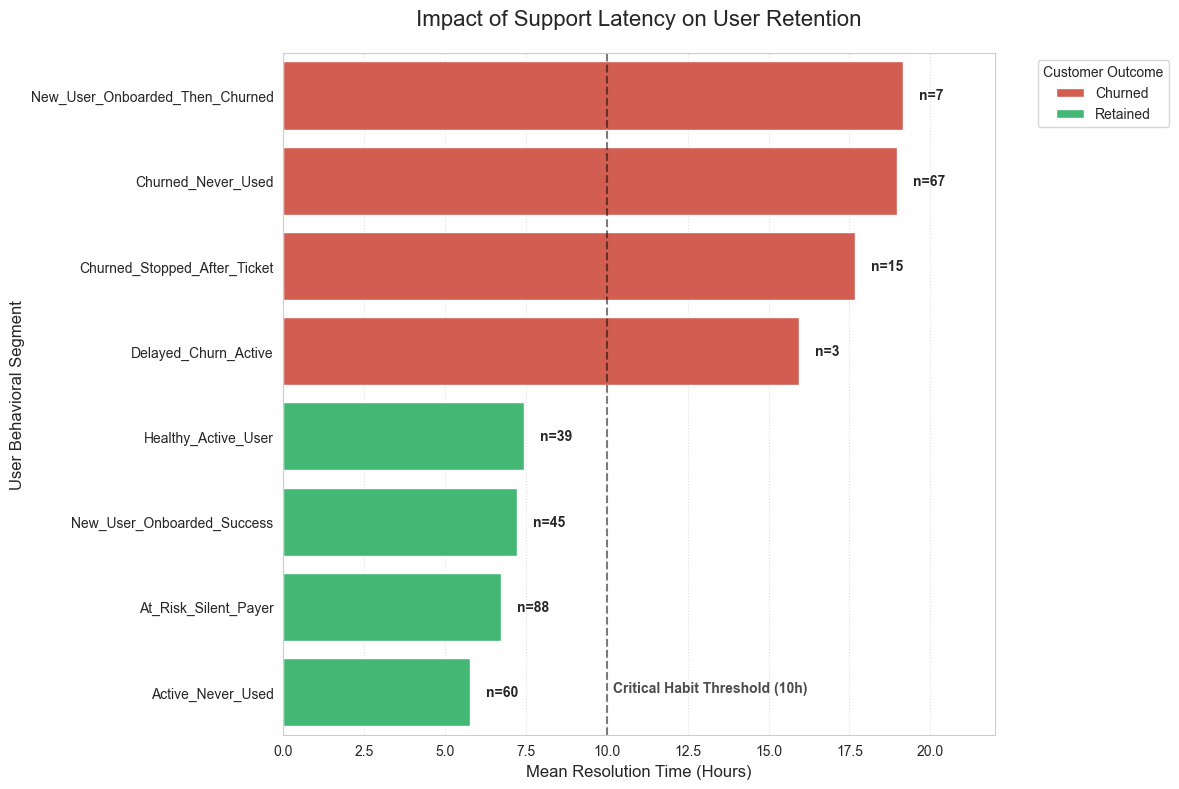

Total users lost specifically in the SLA 'Death Zone': 86


In [60]:
# 1. Sort by resolution time DESCENDING (Longest bars at the top)
df_plot = df_health_stats.sort_values('mean_resolution_time', ascending=False)

# 2. Add Outcome column for coloring
df_plot['Outcome'] = df_plot['logic_key'].apply(lambda x: 'Churned' if x.endswith('Y') else 'Retained')

plt.figure(figsize=(12, 8))
palette = {'Churned': '#e74c3c', 'Retained': '#2ecc71'}

# 3. Create Horizontal Bar Chart
ax = sns.barplot(
    data=df_plot,
    y='segment',
    x='mean_resolution_time',
    hue='Outcome',
    palette=palette,
    dodge=False
)

# 4. Move legend OUTSIDE the plot to avoid overlapping bars
plt.legend(title='Customer Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# 5. Add the "Danger Zone" Threshold line
plt.axvline(x=10, color='black', linestyle='--', alpha=0.5)
plt.text(10.2, 7, 'Critical Habit Threshold (10h)', color='black', fontweight='bold', alpha=0.7)

# 6. Annotate user counts (n=) at the end of bars
for i, row in enumerate(df_plot.itertuples()):
    plt.text(row.mean_resolution_time + 0.5, i, f"n={row.count_segment_users}", va='center', fontweight='bold')
    

# 7. Formatting for Professional Report
plt.title('Impact of Support Latency on User Retention', fontsize=16, pad=20)
plt.xlabel('Mean Resolution Time (Hours)', fontsize=12)
plt.ylabel('User Behavioral Segment', fontsize=12)
plt.xlim(0, 22) # Giving space for the "n=" labels
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Optional addition at the end
saveable_churn = df_health[(df_health['sla_met'] == False) & (df_health['churn_status'] == 'Y')].shape[0]
print(f"Total users lost specifically in the SLA 'Death Zone': {saveable_churn}")


### Operational Thresholds (The Diagnostic View)

- The 10-Hour "Habit Boundary": There is a "Retention Cliff" at 10 hours. Staying under this cap addresses 93.5% of historical churn.

- The 15.9h "Death Zone": Any segment exceeding 15.9 hours results in guaranteed churn. For new users (NNY), 19 hours is a 100% "First Impression" killer.

- The "Silent Crisis" (YNN - Zombies): Our largest group (88 users) is receiving elite support (6.7h) but still not using the app. This is a Product issue, not a Support issue.

=> Strategic KPI: SLA Breach Rate

Current State: 41.98% of our customers are currently being exposed to the "Danger Zone" (>10h wait).

Action Plan: This is our most significant lever. By re-allocating resources to bring this Breach Rate down from 42% to <10%, we can systematically prevent the vast majority of our current churn.

# 7. Final Insights

⭐️ The 10-Hour "Retention Switch"
Support speed is the binary predictor of loyalty. Our data identifies a "Retention Cliff" at 10 hours. Users resolved under this threshold have a 97% retention rate; those exceeding it face a 63% churn probability. Essentially, a 19-hour wait for a new user is functionally equivalent to a 100% churn rate.

⭐️ The "Front Door" Friction (Activation Crisis)
Our highest churn rate (52.8%) occurs in the "Never Used" segment. These users are exiting before their first app event, primarily due to an average support wait of 12.7 hours. We are effectively "breaking the habit" before it even starts by failing the first impression.

⭐️ The "Engagement Shield"
Engagement acts as a powerful buffer against churn. Once a user performs just two events, churn rates drop from 54% to <6%. Furthermore, active users are more "support-tolerant"—they stay loyal even when resolution times are slightly higher, provided they have already found value in the product.

⭐️ The "Silent Crisis" (The Zombie Segment)
The "At-Risk Silent Payers" (YNN) represent our largest group (88 users). Interestingly, this group receives our fastest support (6.7 hours) but still refuses to use the app. This proves that for our largest segment, churn is a Product Engagement issue, not a Support issue.

# 8. BUSINESS RECOMMENDATIONS

🚀 Operational Mandate: The 10-Hour Hard-Cap
We must transition from an "Average Response Time" metric to an SLA Breach Rate metric.

Target: Reduce the SLA Breach Rate from the current 42% to <5%.

Tactic: Prioritize "First Tickets" (Never Used segment) to ensure new users never cross the 10-hour threshold during their onboarding window.

🚀 Emergency Escalation

Any ticket approaching the 14-hour mark should be automatically escalated to a 'Priority-1' status to prevent the user from entering the 15.9-hour guaranteed churn zone.

🚀 Product Intervention: The "Zombie" Re-engagement
Since our largest segment (YNN) is receiving excellent support but not using the app, we need a targeted Product intervention.

Action: Launch an automated re-engagement campaign (email/push) specifically for users who have a "Resolved" ticket but 0 events in the following 48 hours.

🚀 Strategic Tiering: Free-to-Paid Protection
Free tier users are our most "patience-sensitive" (41% churn).

Action: To protect the conversion funnel, implement a "First-Response Boost" for Free users. While we prioritize Enterprise for revenue, we must prioritize Free users for activation to prevent them from leaking out of the ecosystem before they ever pay.

🚀 Refined KPI Tracking
Move beyond tracking "Total Tickets" and begin tracking "Post-Ticket Activity." * New Goal: A successful support interaction should not just be "Closed," it should be measured by whether the user performs at least one app event within 24 hours of resolution.